In [5]:
import matplotlib.pyplot as plt


In [6]:
import re

def extract_last_and_third_last(filename):
    """
    Parse iperf3 per-interval lines in `filename` and return a list of tuples:
    (last_column, third_last_column) == (cwnd, bandwidth)
    """
    pat = re.compile(r"""
        ^\s*\[\s*\d+\]\s+                 # [  5]
        [\d.]+-[\d.]+\s+sec\s+            # 0.00-1.00  sec
        [\d.]+\s+[kMGT]?Bytes\s+          # 5.12 MBytes (transfer)
        ([\d.]+\s+[kMGT]?bits?/sec)\s+    # 43.0 Mbits/sec (bandwidth)
        \d+\s+                            # retransmits
        ([\d.]+\s+[kMGT]?Bytes)           # 267 KBytes (cwnd)
        """, re.IGNORECASE | re.VERBOSE)

    results = []
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pat.search(line)
            if m:
                bandwidth, cwnd = m.group(1), m.group(2)
                cwnd = int(re.sub(r"[^\d]", "", cwnd))
                results.append((cwnd))  # (last, third-last)
    return results


In [7]:
import re

def parse_last_column(filename):
    """
    Parse iperf3 interval lines and return the last column (bitrate) as strings.
    Example return: ["11.5 Mbits/sec", "14.7 Mbits/sec", ...]
    """
    pat = re.compile(r"""
        ^\s*\[\s*\d+\]\s+                 # [  5]
        [\d.]+-[\d.]+\s+sec\s+            # 0.00-1.00  sec
        [\d.]+\s+[kMGT]?Bytes\s+          # 1.38 MBytes
        ([\d.]+\s+[kMGT]?bits?/sec)\s*$   # 11.5 Mbits/sec (capture)
    """, re.IGNORECASE | re.VERBOSE)

    out = []
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = pat.search(line)
            if m:
                print(m)
                out.append(m.group(1))
    return out


In [8]:
tcp_dl_chronos=extract_last_and_third_last("./data/iperf_tcp_chronos")

In [9]:
tcp_dl_chronos

[267, 488, 708, 929, 113, 134, 155, 176, 198, 219]

In [10]:
tcp_dl_cots=extract_last_and_third_last("./data/iperf_tcp_cots")

In [11]:
tcp_dl_cots

[153, 386, 633, 836, 101, 123, 146, 169, 192, 215]

In [12]:
tcp_ul_chronos = extract_last_and_third_last("./data/iperf_tcp_ul_chronos")

In [13]:
# tcp_ul_chronos

In [14]:
# tcp_ul_cots =[577,
# 1044,
# 1044,
# 1075,
# 1060,
# 1146,
# 1146,
# 1146,
# 1146,
# 1146,]

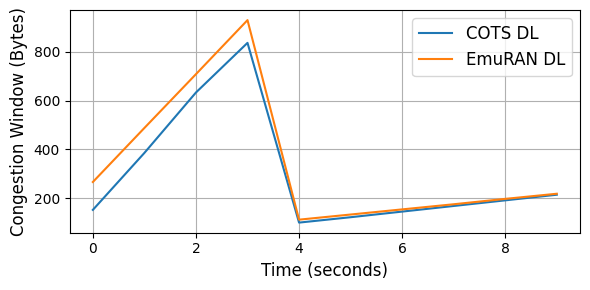

In [15]:
#plot cwnd
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
# plt.plot(tcp_ul_cots)
plt.plot(tcp_dl_cots)
plt.plot(tcp_dl_chronos)
# plt.plot(tcp_ul_chronos)

# plt.title("TCP Upload Congestion Window Size", fontsize=12)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Congestion Window (Bytes)" ,fontsize=12)
plt.grid()
plt.legend(["COTS DL","EmuRAN DL"], fontsize=12)
plt.tight_layout()
plt.savefig("cwnd_comparison.pdf", bbox_inches='tight')
plt.show()

In [16]:
cots = { "TCP DL" : 35.6 ,
         "TCP UL" :  10.1,
         "UDP DL" : 35.1 ,
         "UDP UL" :  10.4
        }

In [17]:
emuran = { "TCP DL" : 36.0 ,
         "TCP UL" :  13.6,
         "UDP DL" : 35,
         "UDP UL" :  10
        }

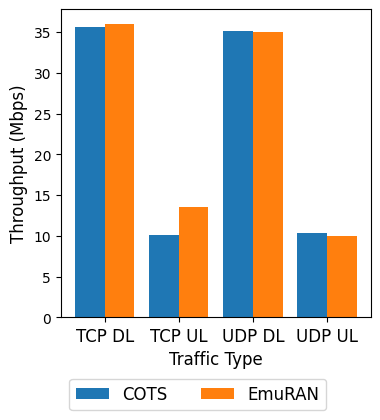

In [28]:
# make bar graph
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
labels = list(cots.keys())
cots_values = list(cots.values())
emuran_values = list(emuran.values())

x = range(len(labels))

plt.bar(x, cots_values, width=0.4, label='COTS', align='center')
plt.bar([p + 0.4 for p in x], emuran_values, width=0.4, label='EmuRAN', align='center')

plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Throughput (Mbps)', fontsize=12)
# plt.title('Throughput Comparison')
plt.xticks([p + 0.2 for p in x], labels , fontsize=12)
plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(0, -0.25), ncol=2)
plt.savefig("throughput_comparison.pdf", bbox_inches='tight')
plt.show()